# Enron Network Analysis (NetworkX + Gephi)

This notebook produces **all required results** for the project rubric (centralities, overlap, community detection, degree distribution, diameter / average shortest path, and comparison to BA/WS/ER).

It also adds three cross-model structural comparisons:
- **assortativity**
- **small-world coefficient**
- **k-core structure**

Designed to be **fast and reproducible** on a laptop by using **approximations** and **sampling** where necessary.


In [1]:
# If needed: pip install python-louvain
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests, gzip, io
from pathlib import Path
from collections import Counter

# Community detection (Louvain)
try:
    import community as community_louvain  # python-louvain
    HAS_LOUVAIN = True
except Exception as e:
    HAS_LOUVAIN = False
    print("python-louvain not available. Install with: pip install python-louvain")

# Reproducibility
RNG = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 120

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = REPO_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = REPO_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
GEPHI_DIR = OUTPUTS_DIR / "gephi"

for path in [RAW_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, GEPHI_DIR]:
    path.mkdir(parents=True, exist_ok=True)


## 1) Download & load Enron graph (SNAP)
We use the SNAP Enron email edge list (directed). For most metrics we analyze the **undirected simple graph** (common in structural analysis).

In [2]:
def download_enron_edge_list(url: str = "https://snap.stanford.edu/data/email-Enron.txt.gz", local_path=None) -> bytes:
    local_path = local_path or (RAW_DATA_DIR / "email-Enron.txt.gz")
    if local_path.exists():
        return local_path.read_bytes()
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    local_path.write_bytes(resp.content)
    return resp.content

def load_enron_graph(make_undirected: bool = True, remove_self_loops: bool = True, data_path=None) -> nx.Graph:
    raw = download_enron_edge_list(local_path=data_path)
    with gzip.GzipFile(fileobj=io.BytesIO(raw)) as gz:
        lines = gz.read().decode("utf-8").splitlines()

    edges = []
    for line in lines:
        if not line or line.startswith("#"):
            continue
        u, v = line.split()
        edges.append((int(u), int(v)))

    Gd = nx.DiGraph()
    Gd.add_edges_from(edges)

    if remove_self_loops:
        Gd.remove_edges_from(nx.selfloop_edges(Gd))

    if make_undirected:
        G = nx.Graph()
        G.add_edges_from(Gd.edges())
        G.remove_edges_from(nx.selfloop_edges(G))
        return G
    return Gd

G = load_enron_graph(make_undirected=True)
Gd = load_enron_graph(make_undirected=False)  # keep directed for optional checks

print("Undirected G:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")
print("Directed Gd:", Gd.number_of_nodes(), "nodes,", Gd.number_of_edges(), "edges")


Undirected G: 36692 nodes, 183831 edges
Directed Gd: 36692 nodes, 367662 edges


## 2) Basic network summary
We also compute the **largest connected component (LCC)** because some metrics (average shortest path, diameter) are only defined for connected graphs.

In [3]:
def basic_summary(G: nx.Graph) -> dict:
    n, m = G.number_of_nodes(), G.number_of_edges()
    avg_deg = 2*m/n if n else float("nan")
    dens = nx.density(G) if n else float("nan")
    comps = list(nx.connected_components(G))
    sizes = sorted([len(c) for c in comps], reverse=True)
    return {
        "n": n,
        "m": m,
        "avg_degree": avg_deg,
        "density": dens,
        "num_components": len(comps),
        "largest_cc_size": sizes[0] if sizes else 0,
    }

summary = basic_summary(G)
pd.DataFrame([summary])


,n,m,avg_degree,density,num_components,largest_cc_size
0,36692,183831,10.020222,0.000273,1065,33696


In [4]:
# Largest connected component
lcc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(lcc_nodes).copy()
print("LCC:", G_lcc.number_of_nodes(), "nodes,", G_lcc.number_of_edges(), "edges")

LCC: 33696 nodes, 180811 edges


## 3) Centralities (required)
We compute:
- **Degree centrality**
- **Betweenness centrality** (approximation for speed)
- **Eigenvector centrality** (may be slower; we run on LCC)
- **PageRank** (on directed graph)

We then list the most central nodes and give interpretive notes.

In [5]:
def top_k(d: dict, k: int = 10):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:k]

# Degree centrality (fast)
deg_cent = nx.degree_centrality(G)

# Betweenness centrality (approx: sample k nodes)
k_sample = min(800, G.number_of_nodes())
btw_cent = nx.betweenness_centrality(G, k=k_sample, seed=42, normalized=True)

# Eigenvector centrality (run on LCC for stability)
eig_cent = nx.eigenvector_centrality(G_lcc, max_iter=1000, tol=1e-6)

# PageRank on directed graph (optional but useful)
pagerank = nx.pagerank(Gd, alpha=0.85)

top_deg = pd.DataFrame(top_k(deg_cent, 10), columns=["node", "degree_centrality"])
top_btw = pd.DataFrame(top_k(btw_cent, 10), columns=["node", "betweenness_centrality"])
top_eig = pd.DataFrame(top_k(eig_cent, 10), columns=["node", "eigenvector_centrality"])
top_pr  = pd.DataFrame(top_k(pagerank, 10), columns=["node", "pagerank"])

top_deg, top_btw, top_eig, top_pr


(   node  degree_centrality
 0  5038           0.037693
 1   273           0.037257
 2   458           0.034368
 3   140           0.033932
 4  1028           0.033905
 5   195           0.031152
 6   370           0.029953
 7  1139           0.029108
 8   136           0.027963
 9   566           0.025183,
    node  betweenness_centrality
 0  5038                0.058929
 1   140                0.057883
 2   458                0.043349
 3   588                0.037085
 4   566                0.036398
 5   273                0.033476
 6  1139                0.031917
 7    46                0.028803
 8  1028                0.027366
 9   195                0.026064,
    node  eigenvector_centrality
 0   136                0.149561
 1   195                0.127076
 2    76                0.126459
 3   370                0.121314
 4  1028                0.112410
 5   273                0.112069
 6   734                0.104399
 7   416                0.100537
 8   175                0.0988

In [6]:
# Consolidated top nodes table (by metric rank)
def rank_table(metric: dict, name: str, k: int = 10) -> pd.DataFrame:
    df = pd.DataFrame(top_k(metric, k), columns=["node", name])
    df["rank_"+name] = np.arange(1, k+1)
    return df

df_top = rank_table(deg_cent, "deg", 10)    .merge(rank_table(btw_cent, "btw", 10), on="node", how="outer")    .merge(rank_table(eig_cent, "eig", 10), on="node", how="outer")    .merge(rank_table(pagerank, "pr", 10), on="node", how="outer")

df_top.sort_values(["rank_deg","rank_btw","rank_eig","rank_pr"], na_position="last").reset_index(drop=True)


,node,deg,rank_deg,btw,rank_btw,eig,rank_eig,pr,rank_pr
0,5038,0.037693,1.0,0.058929,1.0,NaN,NaN,0.011403,1.0
1,273,0.037257,2.0,0.033476,6.0,0.112069,6.0,0.003228,2.0
2,458,0.034368,3.0,0.043349,3.0,NaN,NaN,0.002957,4.0
3,140,0.033932,4.0,0.057883,2.0,NaN,NaN,0.003008,3.0
4,1028,0.033905,5.0,0.027366,9.0,0.112410,5.0,0.002779,7.0
5,195,0.031152,6.0,0.026064,10.0,0.127076,2.0,NaN,NaN
6,370,0.029953,7.0,NaN,NaN,0.121314,4.0,0.002340,9.0
7,1139,0.029108,8.0,0.031917,7.0,NaN,NaN,0.002548,8.0
8,136,0.027963,9.0,NaN,NaN,0.149561,1.0,NaN,NaN
9,566,0.025183,10.0,0.036398,5.0,NaN,NaN,0.002900,6.0


## 4) Top-10% overlap: degree ∩ betweenness (required)
We compute the overlap among the top 10% nodes by degree centrality and betweenness centrality.

Top 10% size: 3670
Overlap count: 2365
Overlap ratio (of top10_deg): 0.6444141689373297


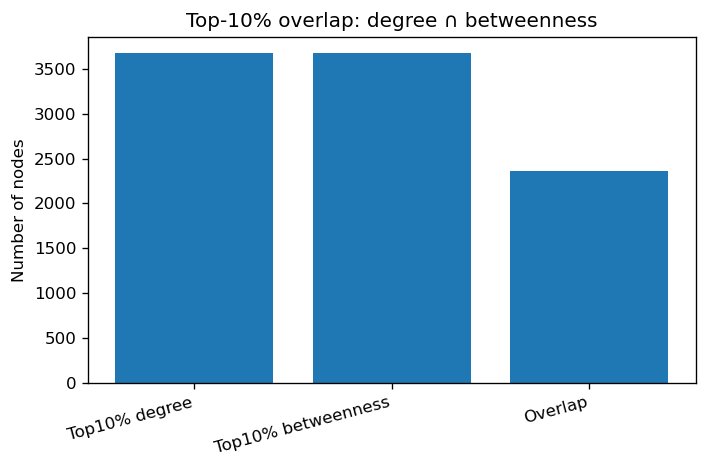

In [7]:
n = G.number_of_nodes()
k10 = int(np.ceil(0.10 * n))

top10_deg = set([u for u,_ in top_k(deg_cent, k10)])
top10_btw = set([u for u,_ in top_k(btw_cent, k10)])
overlap = top10_deg & top10_btw

print("Top 10% size:", k10)
print("Overlap count:", len(overlap))
print("Overlap ratio (of top10_deg):", len(overlap)/len(top10_deg))

# Simple bar chart (report-friendly)
vals = [len(top10_deg), len(top10_btw), len(overlap)]
labels = ["Top10% degree", "Top10% betweenness", "Overlap"]
plt.figure(figsize=(6,4))
plt.bar(labels, vals)
plt.ylabel("Number of nodes")
plt.title("Top-10% overlap: degree ∩ betweenness")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 5) Community detection (required)
We do:
- **Unbounded**: Louvain on the full graph (fast)
- **Bounded**: Girvan–Newman on a **reduced graph** (k-core) because GN is expensive on 33k nodes.

We compare modularity and community size structure.

In [8]:
# --- Unbounded: Louvain on full graph ---
if not HAS_LOUVAIN:
    raise RuntimeError("Install python-louvain to run Louvain: pip install python-louvain")

partition_louvain = community_louvain.best_partition(G, random_state=42)
communities_louvain = {}
for node, cid in partition_louvain.items():
    communities_louvain.setdefault(cid, []).append(node)

sizes_louvain = sorted([len(v) for v in communities_louvain.values()], reverse=True)
print("Louvain communities:", len(sizes_louvain))
print("Largest community sizes (top 10):", sizes_louvain[:10])

# Modularity (NetworkX expects list of sets)
comm_sets = [set(v) for v in communities_louvain.values()]
mod_louvain = nx.algorithms.community.modularity(G, comm_sets)
print("Louvain modularity:", round(mod_louvain, 3))


Louvain communities: 1252
Largest community sizes (top 10): [5996, 4701, 2856, 2821, 1973, 1761, 1691, 1645, 1172, 861]
Louvain modularity: 0.61


NameError: name 'sizes_gn' is not defined

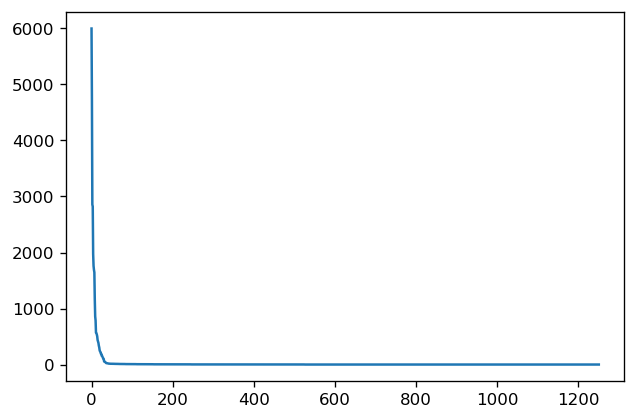

In [9]:
# Community size distributions (Louvain on full vs GN on k-core)
plt.figure(figsize=(6,4))
plt.plot(sorted(sizes_louvain, reverse=True), label="Louvain (full)")
if "sizes_gn" in globals() and "CORE_K" in globals() and "K_BOUNDED" in globals():
    plt.plot(sorted(sizes_gn, reverse=True), label=f"Girvan-Newman (k-core k={CORE_K}, K={K_BOUNDED})")
plt.yscale("log")
plt.xlabel("Community rank (sorted by size)")
plt.ylabel("Community size (log scale)")
plt.title("Community size distributions")
plt.legend()
plt.tight_layout()
plt.show()


## 6) Degree distribution (required)
We provide:
- Degree PDF on log-log axes
- Degree CCDF on log-log axes (more stable)
These plots support the power-law vs Poisson discussion.

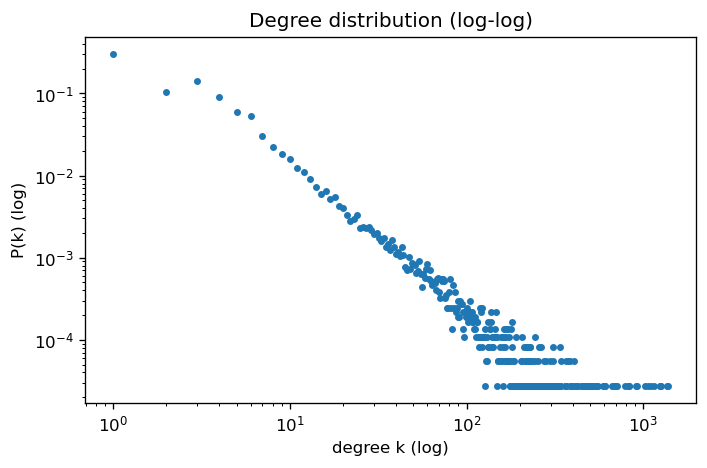

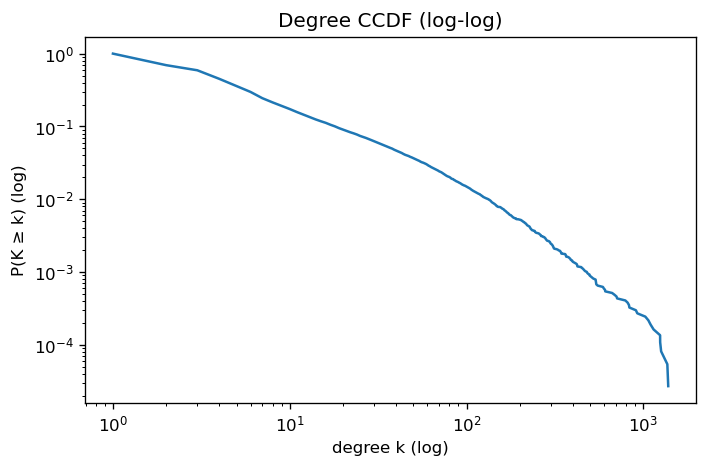

In [10]:
degrees = np.array([d for _, d in G.degree()])
max_k = degrees.max()

# PDF
cnt = Counter(degrees)
ks = np.array(sorted(cnt.keys()))
pk = np.array([cnt[k] for k in ks]) / len(degrees)

plt.figure(figsize=(6,4))
plt.scatter(ks, pk, s=10)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("degree k (log)")
plt.ylabel("P(k) (log)")
plt.title("Degree distribution (log-log)")
plt.tight_layout()
plt.show()

# CCDF: P(K >= k)
ks_sorted = np.sort(degrees)
ccdf_x = np.unique(ks_sorted)
ccdf_y = np.array([(ks_sorted >= k).mean() for k in ccdf_x])

plt.figure(figsize=(6,4))
plt.plot(ccdf_x, ccdf_y)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("degree k (log)")
plt.ylabel("P(K ≥ k) (log)")
plt.title("Degree CCDF (log-log)")
plt.tight_layout()
plt.show()


## 7) Clustering, average shortest path, diameter (required)
Compute on **LCC**. We use an approximation for diameter for speed.

In [11]:
from networkx.algorithms.approximation import diameter as approx_diameter

avg_clust = nx.average_clustering(G_lcc)

# Approximate average shortest path length by sampling BFS trees
def approx_average_shortest_path_length(G: nx.Graph, sample_size: int = 200, seed: int = 42) -> float:
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    sample = rng.choice(nodes, size=min(sample_size, len(nodes)), replace=False)
    dists = []
    for s in sample:
        lengths = nx.single_source_shortest_path_length(G, s)
        # exclude self distance 0
        dists.extend([d for t,d in lengths.items() if t != s])
    return float(np.mean(dists)) if dists else float("nan")

avg_path_approx = approx_average_shortest_path_length(G_lcc, sample_size=200, seed=42)
diam_approx = approx_diameter(G_lcc)

metrics_basic = pd.DataFrame([{
    "avg_clustering": avg_clust,
    "avg_shortest_path_LCC_approx": avg_path_approx,
    "diameter_approx_LCC": diam_approx
}])
metrics_basic


,avg_clustering,avg_shortest_path_LCC_approx,diameter_approx_LCC
0,0.50919,4.022968,13


## 8) Comparison to BA / WS / ER (required)
To keep computations tractable and fair, we compare on a **sampled subgraph** of Enron (n≈5000) and generate BA/WS/ER graphs with similar average degree.

We then compare:
- degree CCDF
- clustering
- avg shortest path
- (approx) diameter

And we add the 3 extra structural comparisons:
1) assortativity
2) small-world coefficient
3) k-core structure

In [12]:
def sample_induced_subgraph(G: nx.Graph, n_sample: int = 5000, seed: int = 42) -> nx.Graph:
    nodes = list(G.nodes())
    rng = np.random.default_rng(seed)
    if n_sample >= len(nodes):
        return G.copy()
    sampled = rng.choice(nodes, size=n_sample, replace=False)
    return G.subgraph(sampled).copy()

# Sample from LCC for connected-ish structure
G_s = sample_induced_subgraph(G_lcc, n_sample=5000, seed=42)
# Keep LCC of sample for path metrics
G_s_lcc = G_s.subgraph(max(nx.connected_components(G_s), key=len)).copy()

n_s, m_s = G_s_lcc.number_of_nodes(), G_s_lcc.number_of_edges()
avg_deg_s = 2*m_s/n_s
print("Sample LCC:", n_s, "nodes,", m_s, "edges, avg degree:", round(avg_deg_s,2))

# Create comparable random graph models
# ER: choose p so expected avg degree ~ avg_deg_s => p ~ avg_deg_s/(n_s-1)
p_er = avg_deg_s/(n_s-1)

# BA: avg degree ~ 2m => choose m ~ avg_deg_s/2
m_ba = max(1, int(round(avg_deg_s/2)))

# WS: choose k ~ avg_deg_s (must be even)
k_ws = int(round(avg_deg_s))
if k_ws % 2 == 1:
    k_ws += 1
k_ws = max(2, min(k_ws, n_s-1))

G_er = nx.erdos_renyi_graph(n_s, p_er, seed=42)
G_ba = nx.barabasi_albert_graph(n_s, m_ba, seed=42)
G_ws = nx.watts_strogatz_graph(n_s, k_ws, 0.1, seed=42)

# Take LCCs for path metrics
def lcc(G):
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()

models = {
    "Enron-sample": G_s_lcc,
    "ER": lcc(G_er),
    "BA": lcc(G_ba),
    "WS": lcc(G_ws),
}
{k: (v.number_of_nodes(), v.number_of_edges()) for k,v in models.items()}


Sample LCC: 1730 nodes, 3460 edges, avg degree: 4.0


{'Enron-sample': (1730, 3460),
 'ER': (1701, 3431),
 'BA': (1730, 3456),
 'WS': (1730, 3460)}

In [13]:
from networkx.algorithms.approximation import diameter as approx_diameter

def approx_average_shortest_path_length(G: nx.Graph, sample_size: int = 200, seed: int = 42) -> float:
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    sample = rng.choice(nodes, size=min(sample_size, len(nodes)), replace=False)
    dists = []
    for s in sample:
        lengths = nx.single_source_shortest_path_length(G, s)
        dists.extend([d for t,d in lengths.items() if t != s])
    return float(np.mean(dists)) if dists else float('nan')

def graph_metrics(G: nx.Graph) -> dict:
    n, m = G.number_of_nodes(), G.number_of_edges()
    avg_deg = 2*m/n if n else float('nan')
    clust = nx.average_clustering(G) if n else float('nan')
    apl = approx_average_shortest_path_length(G, sample_size=200, seed=42) if n else float('nan')
    diam = approx_diameter(G) if n else float('nan')
    assort = nx.degree_assortativity_coefficient(G) if m > 0 else float('nan')
    return {"n": n, "m": m, "avg_degree": avg_deg, "clustering": clust, "avg_path_approx": apl, "diam_approx": diam, "assortativity": assort}

metrics_df = pd.DataFrame({name: graph_metrics(g) for name,g in models.items()}).T
metrics_df


,n,m,avg_degree,clustering,avg_path_approx,diam_approx,assortativity
Enron-sample,1730.0,3460.0,4.000000,0.231450,4.303939,13.0,-0.184545
ER,1701.0,3431.0,4.034098,0.004102,5.570838,12.0,-0.013204
BA,1730.0,3456.0,3.995376,0.015433,4.339919,7.0,-0.054188
WS,1730.0,3460.0,4.000000,0.377110,9.704242,17.0,-0.006323


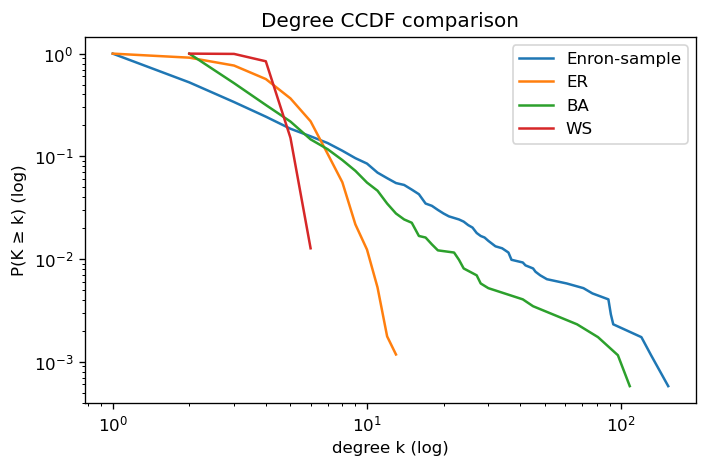

In [14]:
# Degree CCDF comparison (log-log)
plt.figure(figsize=(6,4))
for name, g in models.items():
    deg = np.array([d for _, d in g.degree()])
    deg_sorted = np.sort(deg)
    x = np.unique(deg_sorted)
    y = np.array([(deg_sorted >= k).mean() for k in x])
    plt.plot(x, y, label=name)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("degree k (log)")
plt.ylabel("P(K ≥ k) (log)")
plt.title("Degree CCDF comparison")
plt.legend()
plt.tight_layout()
plt.show()


## 9) Extra structural comparisons (requested)
### 9.1 Assortativity
Assortativity > 0 indicates high-degree nodes connect to high-degree nodes (assortative), while < 0 indicates disassortative mixing.

### 9.2 Small-world coefficient
We use the common heuristic: compare clustering and path length to an ER graph with similar size and density.

### 9.3 k-core structure
We plot k vs number of nodes in the k-core (coreness structure) for each model.

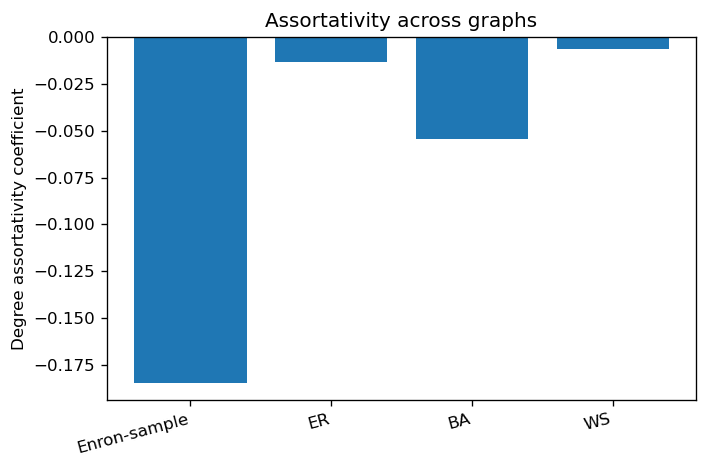

In [15]:
# 9.1 Assortativity (bar)
plt.figure(figsize=(6,4))
plt.bar(metrics_df.index, metrics_df["assortativity"].values)
plt.ylabel("Degree assortativity coefficient")
plt.title("Assortativity across graphs")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


In [16]:
# 9.2 Small-world coefficient (Humphries & Gurney style heuristic)
# sigma = (C/Crand) / (L/Lrand)
# We approximate L with sampled BFS distances (fast).
def small_world_sigma(G: nx.Graph, G_rand: nx.Graph) -> float:
    C = nx.average_clustering(G)
    L = approx_average_shortest_path_length(G, sample_size=200, seed=42)
    Cr = nx.average_clustering(G_rand)
    Lr = approx_average_shortest_path_length(G_rand, sample_size=200, seed=42)
    return (C/Cr) / (L/Lr)

sigma = {}
for name, g in models.items():
    n = g.number_of_nodes()
    m = g.number_of_edges()
    avg_deg = 2*m/n
    p = avg_deg/(n-1)
    g_er_base = lcc(nx.erdos_renyi_graph(n, p, seed=123))
    sigma[name] = small_world_sigma(g, g_er_base)

sigma_df = pd.DataFrame.from_dict(sigma, orient="index", columns=["small_world_sigma"])
sigma_df


,small_world_sigma
Enron-sample,166.704197
ER,1.365707
BA,11.038166
WS,120.465295


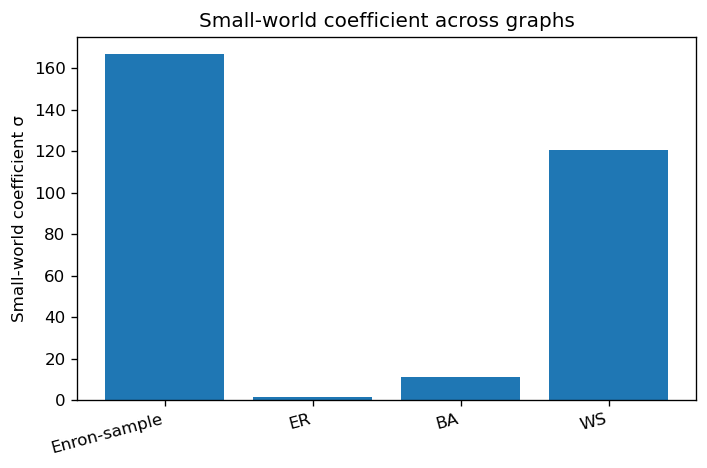

In [17]:
plt.figure(figsize=(6,4))
plt.bar(sigma_df.index, sigma_df["small_world_sigma"].values)
plt.ylabel("Small-world coefficient σ")
plt.title("Small-world coefficient across graphs")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


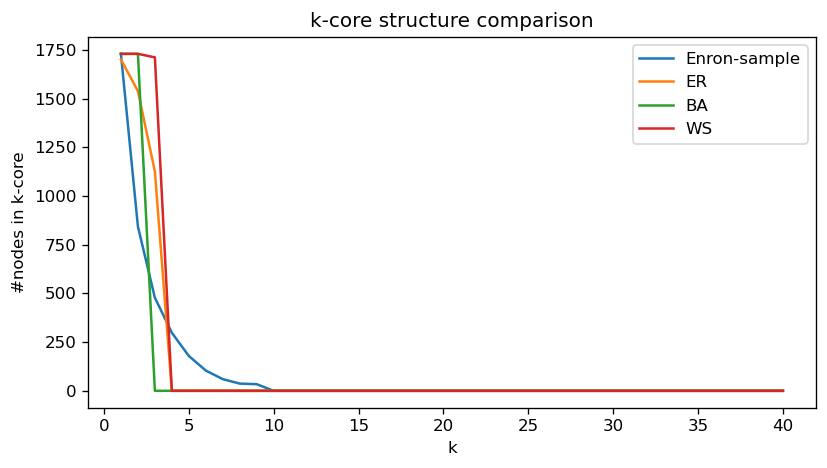

In [18]:
# 9.3 k-core structure curves
def kcore_curve(G: nx.Graph, k_max: int = 40):
    sizes = []
    for k in range(1, k_max+1):
        kc = nx.k_core(G, k=k)
        sizes.append(kc.number_of_nodes())
    return np.arange(1, k_max+1), np.array(sizes)

plt.figure(figsize=(7,4))
for name, g in models.items():
    ks, sizes = kcore_curve(g, k_max=40)
    plt.plot(ks, sizes, label=name)
plt.xlabel("k")
plt.ylabel("#nodes in k-core")
plt.title("k-core structure comparison")
plt.legend()
plt.tight_layout()
plt.show()


## 10) Enron deep-dive (optional but report-valuable)
A classic structural insight for communication networks: **brokers/bridges**.

We identify nodes that have **high betweenness** but **not necessarily the highest degree**, which often indicates cross-group connectors (e.g., coordinators, managers, shared mailboxes).

In [19]:
# Identify broker candidates: high betweenness relative to degree
deg = dict(G.degree())
df_bridge = pd.DataFrame({
    "node": list(btw_cent.keys()),
    "degree": [deg[u] for u in btw_cent.keys()],
    "betweenness": list(btw_cent.values()),
})
df_bridge["btw_per_deg"] = df_bridge["betweenness"] / (df_bridge["degree"] + 1e-9)
df_bridge = df_bridge.sort_values("btw_per_deg", ascending=False)

df_bridge.head(15)


,node,degree,betweenness,btw_per_deg
18798,32880,2,0.001396,0.000698
6604,21726,2,0.001173,0.000586
10731,20317,7,0.002965,0.000424
20741,22644,3,0.001173,0.000391
11386,11733,3,0.001110,0.000370
28862,27837,4,0.001272,0.000318
23946,22869,8,0.002469,0.000309
18680,20719,4,0.001223,0.000306
7462,17094,4,0.001223,0.000306
19493,24195,4,0.001223,0.000306


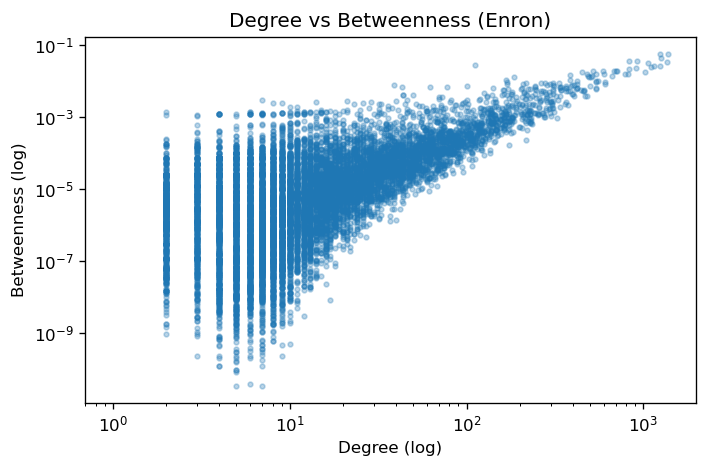

In [20]:
# Scatter: degree vs betweenness (log scales)
plt.figure(figsize=(6,4))
plt.scatter(df_bridge["degree"], df_bridge["betweenness"], s=8, alpha=0.3)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Betweenness (log)")
plt.title("Degree vs Betweenness (Enron)")
plt.tight_layout()
plt.show()


## 11) Export artifacts for Gephi / report
We export:
- full graph
- LCC
- k-core (k=10)

These are useful for Gephi layouts and high-quality figures.

In [21]:
nx.write_gexf(G, GEPHI_DIR / "enron_full.gexf")
nx.write_gexf(G_lcc, GEPHI_DIR / "enron_lcc.gexf")
core_k_to_export = CORE_K if "CORE_K" in globals() else 10
g_core_to_export = G_core if "G_core" in globals() else nx.k_core(G, k=core_k_to_export)
nx.write_gexf(g_core_to_export, GEPHI_DIR / f"enron_kcore_k{core_k_to_export}.gexf")
print(f"Exported Gephi files to: {GEPHI_DIR}")

NameError: name 'G_core' is not defined

## 12) Save key tables
We save centrality top lists and model metrics to CSV for easy report insertion.

In [22]:
top_deg.to_csv(PROCESSED_DATA_DIR / "enron_top_degree.csv", index=False)
top_btw.to_csv(PROCESSED_DATA_DIR / "enron_top_betweenness.csv", index=False)
top_eig.to_csv(PROCESSED_DATA_DIR / "enron_top_eigenvector.csv", index=False)
top_pr.to_csv(PROCESSED_DATA_DIR / "enron_top_pagerank.csv", index=False)
metrics_df.to_csv(PROCESSED_DATA_DIR / "model_metrics_comparison.csv")
sigma_df.to_csv(PROCESSED_DATA_DIR / "small_world_sigma.csv")
df_bridge.head(200).to_csv(PROCESSED_DATA_DIR / "enron_bridge_candidates_top200.csv", index=False)
print(f"Saved CSVs to: {PROCESSED_DATA_DIR}")

Saved CSVs.


## Extra cross-network structural metrics (for comparing Enron vs other real networks)

You mentioned the team wants **the same three metrics** computed on each of the three *real* networks (Collaboration/Erdős, Facebook, Enron) for a clean horizontal comparison:

1. **Assortativity** (degree assortativity coefficient)
2. **Small-world coefficient** \(\sigma\) using an ER random baseline
3. **k-core structure** (curve: *k* vs number of nodes in the k-core)

This section computes them for **Enron** and exports a small JSON/CSV so your teammates can run the *same section* on their networks and then merge results into one comparison table.


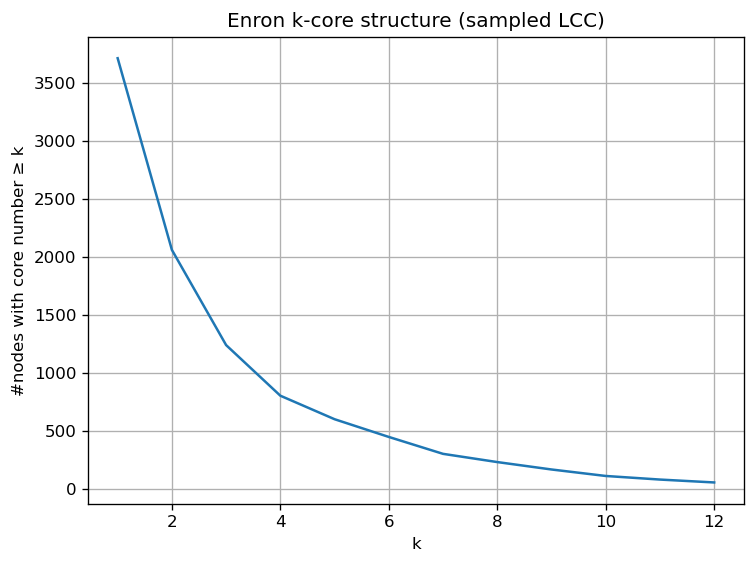

Assortativity (degree): -0.13653521039178662
Small-world sigma: 252.66080581070807
Saved: enron_structural_metrics.json / .csv and enron_kcore_curve.png


In [23]:
import json
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
MAX_N_FOR_SMALLWORLD = 8000   # to keep runtime reasonable; use full graph if smaller

def sample_subgraph(G, n_max=8000, seed=42):
    """If G is large, sample n_max nodes uniformly at random and keep the induced subgraph."""
    n = G.number_of_nodes()
    if n <= n_max:
        return G
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    sampled = rng.choice(nodes, size=n_max, replace=False)
    return G.subgraph(sampled).copy()

def largest_cc_undirected(G):
    Gu = G.to_undirected(as_view=False)
    largest = max(nx.connected_components(Gu), key=len)
    return Gu.subgraph(largest).copy()

def approx_avg_shortest_path_length(G, k_sources=200, seed=42):
    """Approximate average shortest path length by averaging BFS distances from k random sources."""
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    k = min(k_sources, len(nodes))
    sources = rng.choice(nodes, size=k, replace=False)
    dists = []
    for s in sources:
        sp = nx.single_source_shortest_path_length(G, s)
        # exclude self
        dists.extend([d for v, d in sp.items() if v != s])
    return float(np.mean(dists))

def small_world_sigma(G, seed=42):
    """
    Small-world coefficient sigma = (C/C_rand) / (L/L_rand)
    Baseline: ER(n, p) with same expected average degree as G.
    """
    # Use LCC for path/clustering to avoid disconnected issues
    Gc = largest_cc_undirected(G)
    # sample if too large
    Gs = sample_subgraph(Gc, n_max=MAX_N_FOR_SMALLWORLD, seed=seed)
    Gs = largest_cc_undirected(Gs)

    n = Gs.number_of_nodes()
    m = Gs.number_of_edges()
    avg_deg = 2 * m / n

    # clustering
    C = nx.average_clustering(Gs)

    # path length (approx)
    L = approx_avg_shortest_path_length(Gs, k_sources=200, seed=seed)

    # ER baseline with same expected avg degree: p = avg_deg/(n-1)
    p = avg_deg / (n - 1)
    Gr = nx.erdos_renyi_graph(n=n, p=p, seed=seed)
    Gr = largest_cc_undirected(Gr)

    C_rand = nx.average_clustering(Gr)
    L_rand = approx_avg_shortest_path_length(Gr, k_sources=200, seed=seed)

    sigma = (C / C_rand) / (L / L_rand)
    return {
        "n_used": int(n),
        "avg_degree_used": float(avg_deg),
        "C": float(C),
        "L_approx": float(L),
        "C_rand": float(C_rand),
        "L_rand_approx": float(L_rand),
        "sigma": float(sigma),
        "p_er": float(p),
    }

# --- 1) Assortativity ---
G_for_metrics = largest_cc_undirected(G)
G_for_metrics = sample_subgraph(G_for_metrics, n_max=MAX_N_FOR_SMALLWORLD, seed=RANDOM_SEED)
G_for_metrics = largest_cc_undirected(G_for_metrics)

assort = nx.degree_assortativity_coefficient(G_for_metrics)

# --- 2) Small-world coefficient sigma ---
sw = small_world_sigma(G_for_metrics, seed=RANDOM_SEED)

# --- 3) k-core structure curve ---
core = nx.core_number(G_for_metrics)
core_vals = np.array(list(core.values()))
k_max = int(core_vals.max()) if len(core_vals) else 0

k_list = list(range(1, k_max + 1))
nodes_in_kcore = [(core_vals >= k).sum() for k in k_list]

plt.figure()
plt.plot(k_list, nodes_in_kcore)
plt.xlabel("k")
plt.ylabel("#nodes with core number ≥ k")
plt.title("Enron k-core structure (sampled LCC)")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "enron_kcore_curve.png", dpi=300)
plt.show()

# --- Export summary for easy cross-network merge ---
summary = {
    "network": "enron",
    "assortativity_degree": float(assort),
    **{f"smallworld_{k}": v for k, v in sw.items()},
    "kcore_k_max": int(k_max),
}

with open(PROCESSED_DATA_DIR / "enron_structural_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame([summary]).to_csv(PROCESSED_DATA_DIR / "enron_structural_metrics.csv", index=False)

print("Assortativity (degree):", assort)
print("Small-world sigma:", sw["sigma"])
print(f"Saved structural metrics to: {PROCESSED_DATA_DIR}")
print(f"Saved k-core figure to: {FIGURES_DIR / 'enron_kcore_curve.png'}")
